## 1. Load the dataset

The CIFAR-10 dataset is loaded using TensorFlow. It consists of 60,000 images of size 32x32, divided into 10 object categories.

In [5]:
import tensorflow as tf
from tensorflow import keras
# Load CIFAR-10 dataset
cifar_10 = tf.keras.datasets.cifar10.load_data()
(X_train, y_train), (X_test, y_test) = cifar_10

## 2. Data Preprocessing

Before training the CNN, the dataset is preprocessed to improve model performance. This includes merging the original datasets, normalizing pixel values, creating new training, validation and test sets, and encoding the class labels.

The original training and test datasets are combined into a single dataset. This allows us to create our own training, validation and test splits.

In [6]:
# Combine original train and test sets
import numpy as np
X = np.concatenate([X_train, X_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

Pixel values are scaled from range [0, 255] to [0, 1]. Normalization helps the neural network train faster and improves numerical stability during optimization.

In [7]:
# Normalize pixel values
X = X/255.

The dataset is split into training, validation and testing sets using stratified sampling to preserve the class distribution across all subsets.

In [8]:
# Train / Validation / Test split
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, shuffle=True, random_state=42)

In [9]:
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, shuffle=True, random_state=42)

In [10]:
X_train.shape, X_valid.shape, X_test.shape

((36000, 32, 32, 3), (12000, 32, 32, 3), (12000, 32, 32, 3))

The target labels are converted into one-hot encoded vectors so they can be used with the categorical crossentropy loss function during model training.

In [11]:
# One-hot encode labels
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder(sparse_output=False)
y_train_1hot = cat_encoder.fit_transform(y_train)
y_valid_1hot = cat_encoder.transform(y_valid)
y_test_1hot = cat_encoder.transform(y_test)

## 3. Build the CNN Model

A Convolutional Neural Network (CNN) is constructed to automatically learn spatial features from the input images. The architecture consists of convolutional, pooling, dropout and fully connected layers.

In [12]:
# Build CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.40),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.50),

    tf.keras.layers.Dense(10, activation="softmax")
])

## 4. Train the Model

In [13]:
# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

The model is trained using the Adam optimizer and categorical crossentropy loss. Early stopping is applied to prevent overfitting by restoring the best model weights.

In [15]:
# Train model
history = model.fit(
    X_train,
    y_train_1hot,
    epochs=100,
    batch_size=64,
    validation_data=(X_valid, y_valid_1hot),
    callbacks=[early_stopping]
)

Epoch 1/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 61s 101ms/step - accuracy: 0.3968 - loss: 1.7845 - val_accuracy: 0.4179 - val_loss: 1.7080
Epoch 2/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 59s 105ms/step - accuracy: 0.5578 - loss: 1.2381 - val_accuracy: 0.6008 - val_loss: 1.1347
Epoch 3/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 56s 99ms/step - accuracy: 0.6342 - loss: 1.0385 - val_accuracy: 0.6495 - val_loss: 0.9842
Epoch 4/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 57s 102ms/step - accuracy: 0.6779 - loss: 0.9244 - val_accuracy: 0.7225 - val_loss: 0.7848
Epoch 5/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 57s 101ms/step - accuracy: 0.7006 - loss: 0.8580 - val_accuracy: 0.6787 - val_loss: 0.9043
Epoch 6/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 57s 101ms/step - accuracy: 0.7214 - loss: 0.7953 - val_accuracy: 0.7648 - val_loss: 0.6783
Epoch 7/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 57s 102ms/step - accuracy: 0.7369 - loss: 0.7580 - val_accuracy: 0.7237 - val_loss: 0.7874
Epoch 8/100
563/563 ━━━━━━━━━━━━━━━━━━━━ 57s 102ms/step - accuracy: 0.7488 - 

## 5. Model Evaluation

The trained model is evaluated on the test set using accuracy and a confusion matrix to assess its classification performance across all classes.

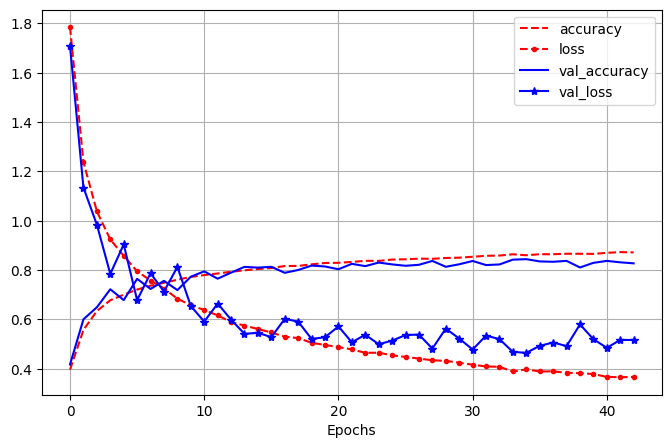

In [25]:
# Accuracy vs Loss plot
import matplotlib.pyplot as plt
import pandas as pd
pd.DataFrame(history.history).plot(
    figsize=(8,5), grid=True, xlabel="Epochs", 
    style=["r--", "r--.", "b-", "b-*"])
plt.savefig("accuracy_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test_1hot)
print("Test	Accuracy: ", test_acc)

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8431 - loss: 0.4733
Test	Accuracy:  0.8430833220481873


In [18]:
# Class names
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [19]:
# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_1hot, axis=1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [21]:
# Classification report
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.87      0.84      0.86      1200
  automobile       0.94      0.93      0.93      1200
        bird       0.81      0.73      0.77      1200
         cat       0.69      0.74      0.72      1200
        deer       0.78      0.86      0.82      1200
         dog       0.79      0.74      0.77      1200
        frog       0.81      0.93      0.86      1200
       horse       0.91      0.84      0.87      1200
        ship       0.92      0.93      0.92      1200
       truck       0.94      0.89      0.91      1200

    accuracy                           0.84     12000
   macro avg       0.85      0.84      0.84     12000
weighted avg       0.85      0.84      0.84     12000



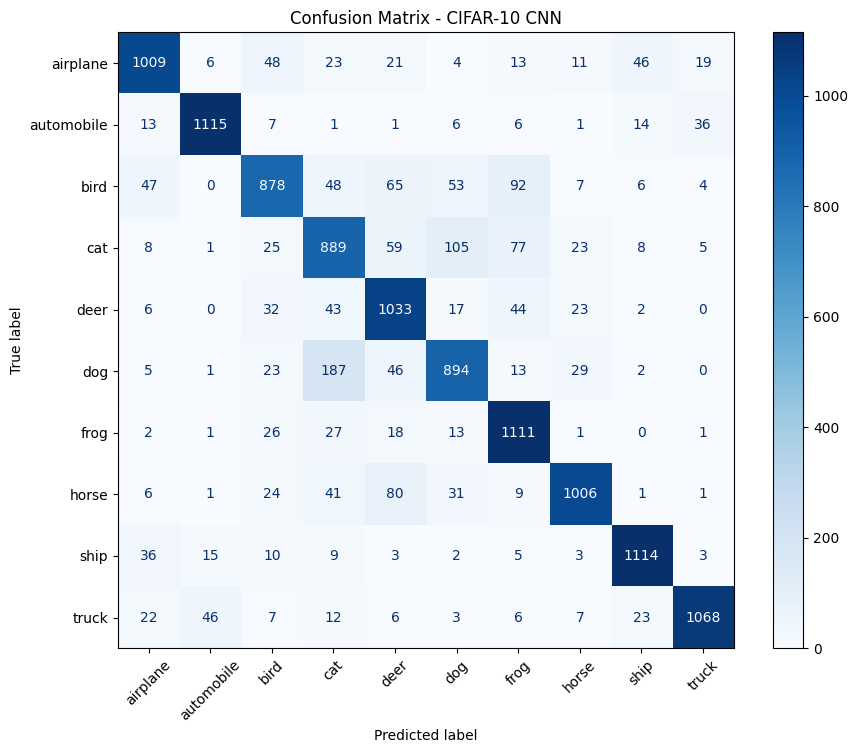

In [26]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - CIFAR-10 CNN")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
# Save model
model.save("cifar10_cnn_model.keras")

## 6. Conclusion

The CNN achieved a test accuracy of approximately 84.3% on the CIFAR-10 dataset.
The model successfully classified images into 10 different categories using convolutional layers, max pooling, dropout and dense layers.
The results indicate that CNNs are effective for image classification tasks.

The model achieved satisfactory performance on the CIFAR-10 dataset. Most classification errors occured between visually similar classes, which is expected due to the low image resolution (32x32 pixels). 